In [1]:
from spin_lattices import SpinLattice, KagomeLattice
from heisenberg_hamiltonians import HeisenbergJ1J2, SpinSystem
from pathlib import Path
from vmc_amplitude import (
    apply_off_diag_to_basis_states,
    apply_diag_to_basis_states,
    LogProbDenseNet,
    find_nbd,
    safe_exp_numpy,
    transfer_signs_to_H,
    true_relsigns,
    almost_true_relsigns,
)
from scipy.sparse import csr_matrix, diags, eye
import numpy as np
from scipy.sparse.linalg import eigsh
import lattice_symmetries as ls
import numpy.typing as npt
from typing import Callable
from nqs_playground_helpers import sample_exactly, SamplingOptions
import torch
from torch import nn
from my_stopwatch import stopwatch
from loguru import logger
import sys
from misc_utils import torch_overlap as overlap, differentiable_safe_exp
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from swo import generate_training_set

2023-09-08 14:43:49.248 | DEBUG    | lattice_symmetries:__init__:50 - Initializing Haskell runtime...
2023-09-08 14:43:49.251 | DEBUG    | lattice_symmetries:__init__:52 - Initializing Chapel runtime...
2023-09-08 14:43:49.371 | DEBUG    | lattice_symmetries:__init__:54 - Setting Python exception handler...
set_python_exception_handler ...


In [2]:
logger.remove()
logger.add(sink=sys.stderr, level="INFO")

1

In [21]:
lattice = KagomeLattice(2, 4)
system = HeisenbergJ1J2(lattice, J1=1, J2=1, ground_state_cache_dir=Path("groundstates"))
system.get_eigenstates(1)

states, _ = sample_exactly(
    log_prob_fn=lambda state: -torch.from_numpy(
        np.log(np.abs(system.get_ground_state_coeffs(state))) * 2
    ),
    basis=system.basis,
    options=SamplingOptions(
        number_samples=10000,
        number_chains=1,
        mode="exact",
        sweep_size=1,
        number_discarded=0,
    ),
    return_all_probs=False,
)
log_prob_fn = LogProbDenseNet(system, n_hidden=512)
overlap(
    torch.exp(log_prob_fn(states).view(-1) * 0.5),
    torch.from_numpy(np.abs(system.get_ground_state_coeffs(states).astype(np.float32))),
)

[Debug]   [LOCALE0]   ls_chpl_enumerate_representatives ...


tensor(0.1733, grad_fn=<DivBackward0>)

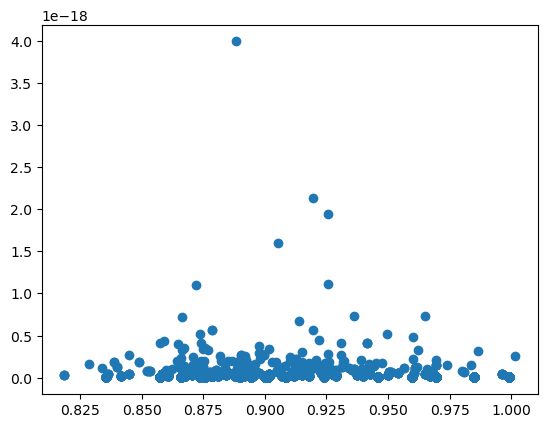

In [22]:
plt.scatter(
    np.exp(log_prob_fn(states).view(-1).detach().numpy() * 0.5),
    (np.abs(system.get_ground_state_coeffs(states).astype(np.float32))),
)

In [68]:
n_samples = 1000
test_samples = 10000
power_iterations = 500
epochs = 100
lr = 1e-3
energy_baseline = 50.0
n_hidden = 512
batch_size = 64

lattice = KagomeLattice(2, 3)
system = HeisenbergJ1J2(lattice, J2=1, use_symmetries=False, spin_inversion=None)
system.get_eigenstates(1)

log_prob_fn = LogProbDenseNet(system, n_hidden=n_hidden)

stopwatch.reset()

optimizer = torch.optim.Adam(log_prob_fn.parameters(), lr=lr)
criterion = torch.nn.MSELoss()

true_amplitudes = torch.from_numpy(
    np.abs(system.get_ground_state_coeffs(system.basis.states))
).float()

df_list = []

for iteration in range(power_iterations):
    all_states, _ = sample_exactly(
        log_prob_fn,
        system.basis,
        SamplingOptions(
            number_samples=n_samples + test_samples,
            number_chains=1,
            mode="exact",
            sweep_size=1,
            number_discarded=0,
        ),
        return_all_probs=False,
    )
    all_states = all_states.view(-1)

    states = all_states[:n_samples]
    states_test = all_states[n_samples:]

    all_target = generate_training_set(
        hamiltonian=system.hamiltonian,
        states=all_states.detach().numpy(),
        log_prob_fn=lambda s: log_prob_fn(s).detach().numpy().reshape(-1),
        relsigns_fn=almost_true_relsigns(system, eps=0.0),
        energy_baseline=energy_baseline,
    )
    all_target = torch.from_numpy(all_target).float()

    target = all_target[:n_samples]
    target_test = all_target[n_samples:]

    # Create a TensorDataset from your inputs X and Y
    dataset = TensorDataset(states, target)

    dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

    log_prob_fn = LogProbDenseNet(system, n_hidden=n_hidden)

    optimizer = torch.optim.Adam(log_prob_fn.parameters(), lr=lr)

    # writer = SummaryWriter(
    #     log_dir=(
    #         f"experiments/{datetime.now().strftime('%Y_%m_%d')}_dense_xor_supervised/{datetime.now().strftime('%H_%M_%S')}"
    #         #        f"xor={xor_masks_idxs}_ch=_{channels}_{lr=}_{blocks=}"
    #     )
    # )

    initial_ground_state_overlap_full = overlap(
        torch.exp(log_prob_fn(system.basis.states).view(-1) * 0.5), true_amplitudes
    )

    initial_ground_state_overlap_train = overlap(
        torch.exp(log_prob_fn(states).view(-1) * 0.5), true_amplitudes[system.basis.index(states)]
    )

    initial_ground_state_overlap_test = overlap(
        torch.exp(log_prob_fn(states_test).view(-1) * 0.5), true_amplitudes[system.basis.index(states_test)]
    )

    target_ground_state_overlap_train = overlap(
        torch.exp(target.view(-1) * 0.5), true_amplitudes[system.basis.index(states)]
    )

    target_ground_state_overlap_test = overlap(
        torch.exp(target_test.view(-1) * 0.5), true_amplitudes[system.basis.index(states_test)]
    )

    
    for epoch in range(epochs):
        running_loss = 0.0
        for action_index, data in enumerate(dataloader, 0):
            # Get the inputs and move them to the specified device
            inputs, log_probs = data

            # Zero the parameter gradients
            optimizer.zero_grad()

            # Forward pass
            outputs = log_prob_fn(inputs)

            # weights = torch.exp(2 * log_amplitudes)
            # weights = weights / torch.sum(weights)

            # Compute loss
            # loss = (
            #     # weights @
            #     criterion(outputs, log_probs.view(-1, 1))
            # )  # Reshape labels to match output shape
            loss = 1 - overlap(
                differentiable_safe_exp(outputs.view(-1) * 0.5),
                differentiable_safe_exp(log_probs * 0.5),
            )
            # Backward pass and optimize
            loss.backward()
            optimizer.step()

            # Collect loss
            running_loss += loss.item()

    new_ground_state_overlap_full = overlap(
        torch.exp(log_prob_fn(system.basis.states).view(-1) * 0.5), true_amplitudes
    )

    new_ground_state_overlap_train = overlap(
        torch.exp(log_prob_fn(states).view(-1) * 0.5), true_amplitudes[system.basis.index(states)]
    )

    new_ground_state_overlap_test = overlap(
        torch.exp(log_prob_fn(states_test).view(-1) * 0.5), true_amplitudes[system.basis.index(states_test)]
    )

    df_list.append(
        {
            "iteration": iteration,
            "initial_ground_state_overlap_full": initial_ground_state_overlap_full.item(),
            "initial_ground_state_overlap_train": initial_ground_state_overlap_train.item(),
            "initial_ground_state_overlap_test": initial_ground_state_overlap_test.item(),
            "target_ground_state_overlap_train": target_ground_state_overlap_train.item(),
            "target_ground_state_overlap_test": target_ground_state_overlap_test.item(),
            "new_ground_state_overlap_full": new_ground_state_overlap_full.item(),
            "new_ground_state_overlap_train": new_ground_state_overlap_train.item(),
            "new_ground_state_overlap_test": new_ground_state_overlap_test.item(),
        }
    )

        # # Add average loss per epoch to TensorBoard
        # writer.add_scalar("Training Loss", running_loss / len(dataloader), epoch)

        # Calculate overlaps and add them to TensorBoard
        # overlap_train = overlap(
        #     torch.exp(log_prob_fn(states).view(-1) * 0.5), torch.exp(target * 0.5)
        # )
        # logger.info(f"Overlap with target (train): {overlap_train.item()}")

        # overlap_test = overlap(
        #     torch.exp(log_prob_fn(states_test).view(-1) * 0.5),
        #     torch.exp(target_test * 0.5),
        # )
        # logger.info(f"Overlap with target (test): {overlap_test.item()}")

        # writer.add_scalar("train/overlap", overlap_train, epoch)
        # # writer.add_scalar('Overlap Test', overlap_test, epoch)
        # writer.add_scalar("test/overlap", overlap_test, epoch)
    
    logger.info(f"{iteration}. Full overlap with ground true: {new_ground_state_overlap_full.item()}")
    # print("Finished Training")

[Debug]   [LOCALE0]   ls_chpl_enumerate_representatives ...
2023-08-17 17:22:17.543 | INFO     | __main__:<module>:170 - 0. Full overlap with ground true: 0.5259537696838379
2023-08-17 17:22:23.779 | INFO     | __main__:<module>:170 - 1. Full overlap with ground true: 0.5902837514877319
2023-08-17 17:22:30.112 | INFO     | __main__:<module>:170 - 2. Full overlap with ground true: 0.6399860978126526
2023-08-17 17:22:36.387 | INFO     | __main__:<module>:170 - 3. Full overlap with ground true: 0.6779298186302185
2023-08-17 17:22:42.689 | INFO     | __main__:<module>:170 - 4. Full overlap with ground true: 0.7073498964309692
2023-08-17 17:22:48.962 | INFO     | __main__:<module>:170 - 5. Full overlap with ground true: 0.7253203392028809
2023-08-17 17:22:55.251 | INFO     | __main__:<module>:170 - 6. Full overlap with ground true: 0.7379944920539856
2023-08-17 17:23:01.565 | INFO     | __main__:<module>:170 - 7. Full overlap with ground true: 0.7442205548286438
2023-08-17 17:23:07.826 | IN

KeyboardInterrupt: 

In [69]:
df = pd.DataFrame(df_list)

In [70]:
df

,iteration,initial_ground_state_overlap_full,initial_ground_state_overlap_train,initial_ground_state_overlap_test,target_ground_state_overlap_train,target_ground_state_overlap_test,new_ground_state_overlap_full,new_ground_state_overlap_train,new_ground_state_overlap_test
0,0,0.449885,0.430110,0.455482,0.543104,0.571459,0.525954,0.542074,0.529675
1,1,0.448843,0.477590,0.494907,0.663702,0.675844,0.590284,0.661895,0.627913
2,2,0.448567,0.533300,0.531266,0.748160,0.750360,0.639986,0.745923,0.696277
3,3,0.449526,0.563273,0.568247,0.789806,0.802242,0.677930,0.786867,0.747024
4,4,0.449613,0.589906,0.600405,0.830572,0.837153,0.707350,0.827821,0.785342
5,5,0.449560,0.621979,0.615803,0.847619,0.849093,0.725320,0.844614,0.790962
6,6,0.450741,0.623591,0.638775,0.853234,0.862606,0.737994,0.850161,0.810723
7,7,0.450080,0.661885,0.641255,0.880966,0.867149,0.744221,0.878294,0.812337
8,8,0.449474,0.663223,0.654274,0.893860,0.876384,0.753905,0.891094,0.828558
9,9,0.449650,0.669815,0.652882,0.882673,0.879492,0.759871,0.879112,0.829570


In [71]:
predicted_probs = torch.exp(log_prob_fn(system.basis.states).view(-1))
predicted_probs /= predicted_probs.sum()
predicted_ipr = (predicted_probs**2).sum().item()

In [72]:
predicted_ipr

0.000218354252865538

In [73]:
(system.get_ground_state_coeffs(system.canonical_basis.states) ** 4).sum()

0.000420467020452604

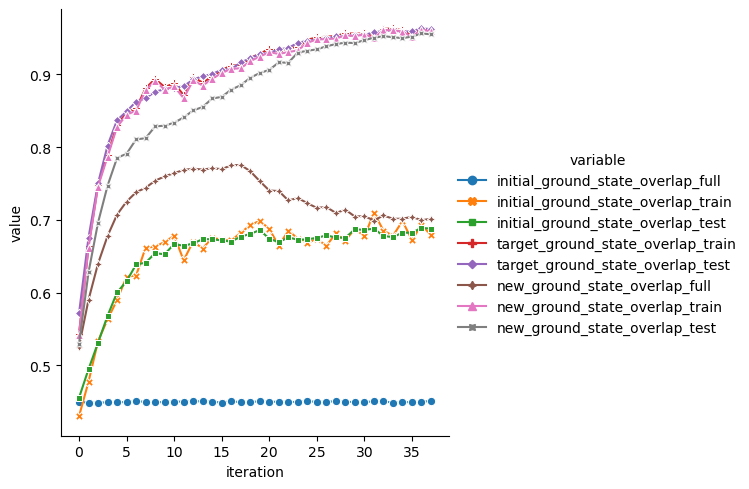

In [74]:
sns.relplot(
    df.melt(id_vars=["iteration"]),
    x="iteration",
    y="value",
    hue="variable",
    kind="line",
    style="variable",
    dashes=False,
    markers=True,
)

In [75]:
df

,iteration,initial_ground_state_overlap_full,initial_ground_state_overlap_train,initial_ground_state_overlap_test,target_ground_state_overlap_train,target_ground_state_overlap_test,new_ground_state_overlap_full,new_ground_state_overlap_train,new_ground_state_overlap_test
0,0,0.449885,0.430110,0.455482,0.543104,0.571459,0.525954,0.542074,0.529675
1,1,0.448843,0.477590,0.494907,0.663702,0.675844,0.590284,0.661895,0.627913
2,2,0.448567,0.533300,0.531266,0.748160,0.750360,0.639986,0.745923,0.696277
3,3,0.449526,0.563273,0.568247,0.789806,0.802242,0.677930,0.786867,0.747024
4,4,0.449613,0.589906,0.600405,0.830572,0.837153,0.707350,0.827821,0.785342
5,5,0.449560,0.621979,0.615803,0.847619,0.849093,0.725320,0.844614,0.790962
6,6,0.450741,0.623591,0.638775,0.853234,0.862606,0.737994,0.850161,0.810723
7,7,0.450080,0.661885,0.641255,0.880966,0.867149,0.744221,0.878294,0.812337
8,8,0.449474,0.663223,0.654274,0.893860,0.876384,0.753905,0.891094,0.828558
9,9,0.449650,0.669815,0.652882,0.882673,0.879492,0.759871,0.879112,0.829570


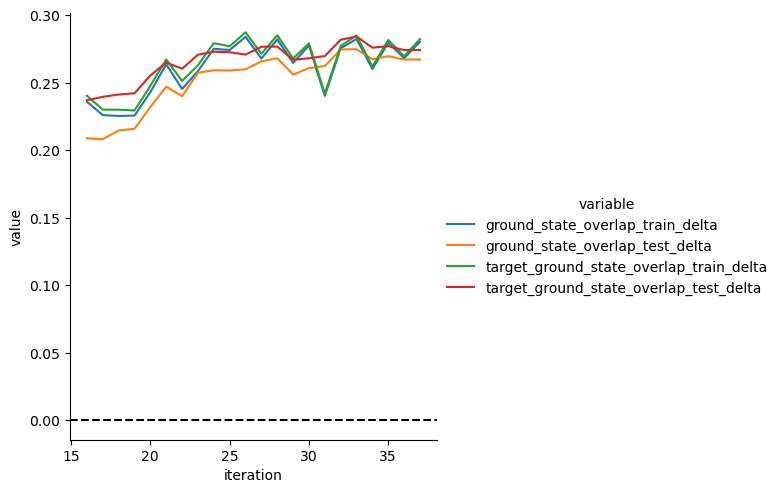

In [77]:
sns.relplot(
    df.query("iteration > 15")
    .assign(
        ground_state_overlap_train_delta=lambda x: x["new_ground_state_overlap_train"]
        - x["initial_ground_state_overlap_train"],
        ground_state_overlap_test_delta=lambda x: x["new_ground_state_overlap_test"]
        - x["initial_ground_state_overlap_test"],
        target_ground_state_overlap_train_delta=lambda x: x["target_ground_state_overlap_train"]
        - x["initial_ground_state_overlap_train"],
        target_ground_state_overlap_test_delta=lambda x: x["target_ground_state_overlap_test"]
        - x["initial_ground_state_overlap_test"],
    )[
        [
            "iteration",
            "ground_state_overlap_train_delta",
            "ground_state_overlap_test_delta",
            "target_ground_state_overlap_train_delta",
            "target_ground_state_overlap_test_delta",
        ]
    ]
    .melt(id_vars="iteration"),
    x="iteration",
    y="value",
    hue="variable",
    kind="line",
)
plt.axhline(0, color="black", linestyle="--")

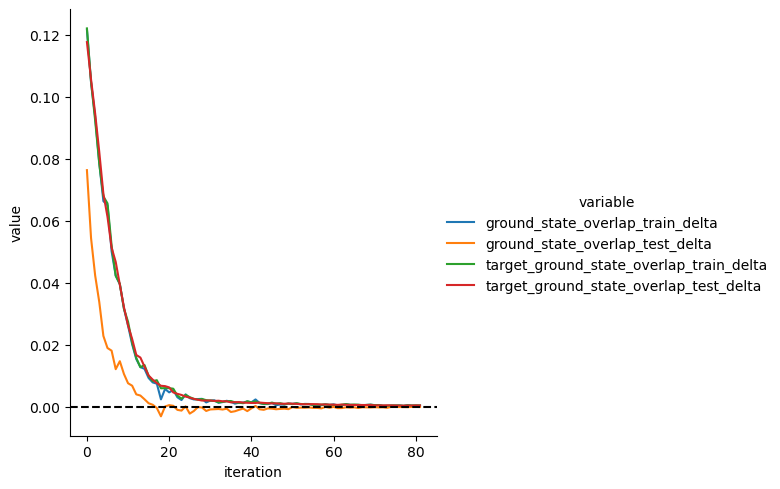

In [67]:
sns.relplot(
    df.query("iteration > -1")
    .assign(
        ground_state_overlap_train_delta=lambda x: x["new_ground_state_overlap_train"]
        - x["initial_ground_state_overlap_train"],
        ground_state_overlap_test_delta=lambda x: x["new_ground_state_overlap_test"]
        - x["initial_ground_state_overlap_test"],
        target_ground_state_overlap_train_delta=lambda x: x["target_ground_state_overlap_train"]
        - x["initial_ground_state_overlap_train"],
        target_ground_state_overlap_test_delta=lambda x: x["target_ground_state_overlap_test"]
        - x["initial_ground_state_overlap_test"],
    )[
        [
            "iteration",
            "ground_state_overlap_train_delta",
            "ground_state_overlap_test_delta",
            "target_ground_state_overlap_train_delta",
            "target_ground_state_overlap_test_delta",
        ]
    ]
    .melt(id_vars="iteration"),
    x="iteration",
    y="value",
    hue="variable",
    kind="line",
)
plt.axhline(0, color="black", linestyle="--")

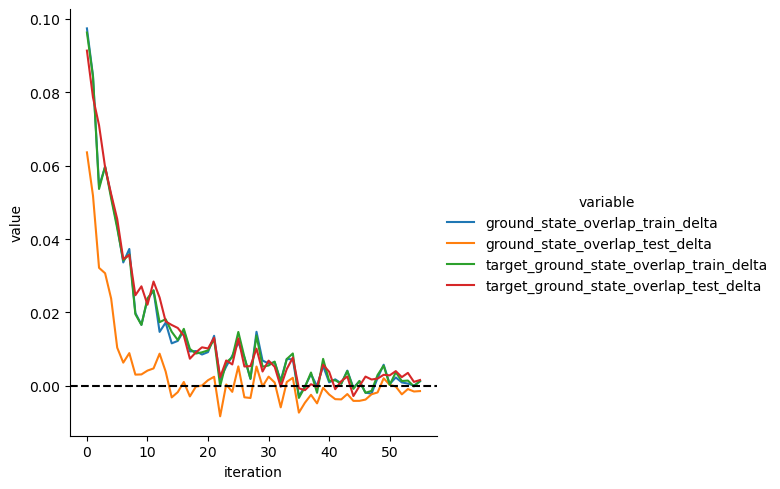

In [52]:
sns.relplot(
    df.query("iteration > -1")
    .assign(
        ground_state_overlap_train_delta=lambda x: x["new_ground_state_overlap_train"]
        - x["initial_ground_state_overlap_train"],
        ground_state_overlap_test_delta=lambda x: x["new_ground_state_overlap_test"]
        - x["initial_ground_state_overlap_test"],
        target_ground_state_overlap_train_delta=lambda x: x["target_ground_state_overlap_train"]
        - x["initial_ground_state_overlap_train"],
        target_ground_state_overlap_test_delta=lambda x: x["target_ground_state_overlap_test"]
        - x["initial_ground_state_overlap_test"],
    )[
        [
            "iteration",
            "ground_state_overlap_train_delta",
            "ground_state_overlap_test_delta",
            "target_ground_state_overlap_train_delta",
            "target_ground_state_overlap_test_delta",
        ]
    ]
    .melt(id_vars="iteration"),
    x="iteration",
    y="value",
    hue="variable",
    kind="line",
)
plt.axhline(0, color="black", linestyle="--")

In [17]:
def truncated_overlap(predicted_amplitudes, eigenvect, start, stop):
    sort_order = np.argsort(predicted_amplitudes)[start:stop]
    return overlap_numpy(predicted_amplitudes[sort_order], eigenvect[sort_order])

In [19]:
for i, (eigenval, eigenvect) in enumerate(zip(eigenvals, eigenvects.T)):
    print(
        f"{i}. "
        f"{eigenval=}, {overlap_numpy(predicted_amplitudes, eigenvect)=:.3f}, "
        f"{overlap_numpy(predicted_amplitudes, eigenvect)=:.3f}"
    )

0. eigenval=80.41087417918975, overlap_numpy(predicted_amplitudes, eigenvect)=-0.002, overlap_numpy(predicted_amplitudes, eigenvect)=-0.002
1. eigenval=80.4108741791902, overlap_numpy(predicted_amplitudes, eigenvect)=-0.001, overlap_numpy(predicted_amplitudes, eigenvect)=-0.001
2. eigenval=80.41087417919039, overlap_numpy(predicted_amplitudes, eigenvect)=0.002, overlap_numpy(predicted_amplitudes, eigenvect)=0.002
3. eigenval=80.43272389333097, overlap_numpy(predicted_amplitudes, eigenvect)=0.002, overlap_numpy(predicted_amplitudes, eigenvect)=0.002
4. eigenval=80.43272389333187, overlap_numpy(predicted_amplitudes, eigenvect)=-0.002, overlap_numpy(predicted_amplitudes, eigenvect)=-0.002
5. eigenval=80.4327238933319, overlap_numpy(predicted_amplitudes, eigenvect)=0.001, overlap_numpy(predicted_amplitudes, eigenvect)=0.001
6. eigenval=80.54832191409514, overlap_numpy(predicted_amplitudes, eigenvect)=-0.005, overlap_numpy(predicted_amplitudes, eigenvect)=-0.005
7. eigenval=80.5483219140952

In [ ]:
0.7**2 + 0.6**2 + 0.2**2

0.8899999999999999

In [ ]:
q = eigenvects[:, 39] * 0.5 + eigenvects[:, 32] * 0.5

In [ ]:
overlap_numpy(M_with_signs @ q, q)

0.9999969910552985

In [21]:
def plot_distance(predicted_amplitudes, eigenvect, window=100, label=""):
    sort_order = np.argsort(-predicted_amplitudes)
    plt.plot(
        [
            truncated_overlap(predicted_amplitudes, eigenvect, i, i + window)
            for i in range(0, len(predicted_amplitudes) - window, window)
        ],
        label=label,
    )
    # plt.plot(predicted_amplitudes[sort_order])

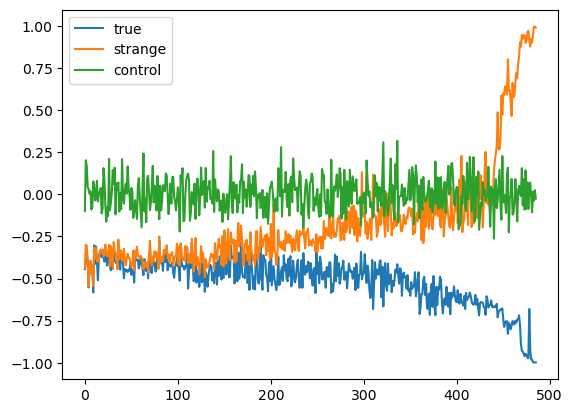

In [22]:
plot_distance(predicted_amplitudes, eigenvects[:, 39], label="true")
plot_distance(predicted_amplitudes, eigenvects[:, 32], label="strange")
plot_distance(predicted_amplitudes, eigenvects[:, 30], label="control")
plt.legend()

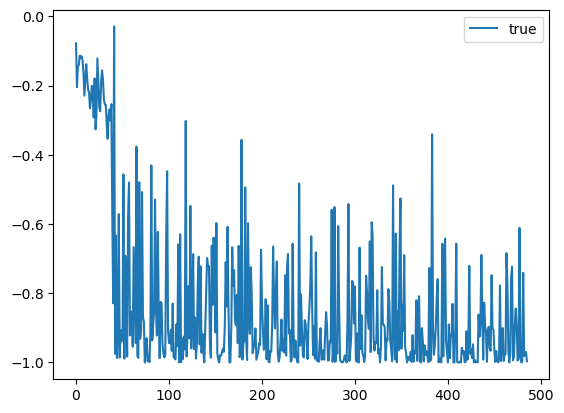

In [27]:
plot_distance(np.abs(eigenvects[:, 32]), eigenvects[:, 39], label="true")
# plot_distance(predicted_amplitudes, , label='control')
plt.legend()

In [35]:
sorted(
    [
        (np.abs(overlap_numpy(np.abs(eigenvects[:, i]), eigenvects[:, 39])), i)
        for i in range(40)
    ]
)

[(0.5080889901217034, 36),
 (0.5471087533771598, 30),
 (0.5623257939898711, 31),
 (0.5725894876497576, 29),
 (0.5804911757247583, 9),
 (0.592839207208757, 12),
 (0.5963717375207368, 14),
 (0.6024535396889609, 13),
 (0.6251684783732167, 17),
 (0.632365685561331, 1),
 (0.6369516823075597, 0),
 (0.6414597021746236, 15),
 (0.6415077806425101, 16),
 (0.6417120372303068, 2),
 (0.6417238122422682, 21),
 (0.6461697251595383, 20),
 (0.6462690211156571, 22),
 (0.6509254915192184, 10),
 (0.6539411861771934, 23),
 (0.6611026979222373, 24),
 (0.664925506061529, 35),
 (0.6669639552064476, 25),
 (0.6765987782441611, 3),
 (0.6767867854187702, 28),
 (0.6770057470168648, 4),
 (0.6784761569228384, 5),
 (0.6794453595965398, 19),
 (0.6808317351595014, 26),
 (0.6825699949821143, 27),
 (0.6848847834407994, 18),
 (0.6935149636639522, 33),
 (0.693947473514594, 38),
 (0.6989476891260374, 37),
 (0.7101069338583741, 34),
 (0.7448502432393513, 11),
 (0.7991075830941066, 8),
 (0.7997744186812201, 6),
 (0.8005954128